In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load Data

In [2]:
main_path = "./lstm_process_data/"

## Load PHQ9 Data

In [3]:
phq9_full = pd.read_csv(f"{main_path}phq9_transformed_full.csv")
phq9_pre = pd.read_csv(f"{main_path}phq9_transformed_pre.csv")
phq9_post = pd.read_csv(f"{main_path}phq9_transformed_post.csv")

# Rename column
phq9_full = phq9_full.rename(columns={"uid": "user_id"})
phq9_pre = phq9_pre.rename(columns={"uid": "user_id"})
phq9_post = phq9_post.rename(columns={"uid": "user_id"})

display(phq9_pre)

,user_id,pre_little_interest_or_pleasure_in_doing_things,pre_feeling_down_depressed_hopeless,pre_trouble_falling_or_staying_asleep_or_sleeping_too_much,pre_feeling_tired_or_having_little_energy,pre_poor_appetite_or_overeating,pre_feeling_bad_about_yourself_or_that_you_are_a_failure_or_have_let_yourself_or_your_family_down,pre_trouble_concentrating_on_things_such_as_reading_the_newspaper_or_watching_television,pre_moving_or_speaking_so_slowly_that_other_people_could_have_noticed_or_the_opposite_being_so_figety_or_restless_that_you_have_been_moving_around_a_lot_more_than_usual,pre_thoughts_that_you_would_be_better_off_dead_or_of_hurting_yourself,pre_response,pre_total_score,pre_depression_severity,pre_depression_class
0,u00,0,1,0,1,0,0,0,0,0,0,2,Minimal depression,0.0
1,u01,1,1,1,1,0,1,0,0,0,2,5,Mild depression,1.0
2,u02,2,1,2,2,2,1,1,2,0,1,13,Moderate depression,2.0
3,u03,0,1,0,0,0,0,0,1,0,1,2,Minimal depression,0.0
4,u04,1,1,0,1,1,1,1,0,0,1,6,Mild depression,1.0
5,u05,0,0,1,0,1,0,0,0,0,-1,2,Minimal depression,0.0
6,u07,1,1,0,1,2,1,1,0,0,0,7,Mild depression,1.0
7,u08,1,1,0,0,1,1,1,0,0,0,5,Mild depression,1.0
8,u09,0,0,1,1,1,0,1,0,0,0,4,Minimal depression,0.0
9,u10,0,0,0,0,0,0,0,0,0,-1,0,NaN,NaN


## Load gpa information

In [4]:
# Load data
gpa = pd.read_csv("./../cleaned_data/education/grades.csv")

# Keep only relevant columns
gpa = gpa[["uid", "gpa all"]]

# Rename column
gpa = gpa[["uid", "gpa all"]].rename(columns={"uid": "user_id", "gpa all": "gpa"})


# Convert GPA to float
gpa["gpa"] = pd.to_numeric(gpa["gpa"], errors="coerce")

# Display head to verify
display(gpa.head())

,user_id,gpa
0,u01,2.863
1,u02,3.505
2,u04,3.029
3,u05,3.679
4,u07,3.474


## Load daily data

In [5]:
df_daily = pd.read_csv(f"{main_path}cleaned_daily_data.csv")
df_daily1 = df_daily.dropna()

# print(df_daily.head(1))
# print(df_daily1.head(1))

print(f"The daily dataframe length is {len(df_daily)}")
print(f"The daily dataframe with no nan values length is {len(df_daily1)}")

The daily dataframe length is 2883
The daily dataframe with no nan values length is 131


In [6]:
display(df_daily.head())

,date,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,...,schedule,happy,happyornot,sad,sadornot,sleep_hours,sleep_quality,sleepiness,number,level
0,2013-03-24 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.0,0.0,0.0,1.0,NaN
1,2013-03-25 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.0,0.0,0.0,1.0,1.0
2,2013-03-26 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.0,1.0,0.0,1.0,1.0
3,2013-03-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.0,1.0,0.0,3.0,0.0
4,2013-03-28 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5.0,1.0,0.0,2.0,2.0


In [7]:
df_daily = df_daily.sort_values(by=["user_id", "date"])
df_daily_filled = (
    df_daily.set_index(["user_id", "date"])
    .groupby("user_id")
    .ffill()
    .bfill()
    .reset_index()
)
print("Before filling: NaNs in df_daily")
print(df_daily.isna().sum().sort_values(ascending=False).head())

print("\nAfter filling: NaNs in df_daily_filled")
print(df_daily_filled.isna().sum().sort_values(ascending=False).head())

Before filling: NaNs in df_daily
grade                   2599
effort                  2599
challenge               2599
positive_event_score    2172
has_negative_text       2172
dtype: int64

After filling: NaNs in df_daily_filled
user_id              0
date                 0
emotion_range        0
has_positive_text    0
has_negative_text    0
dtype: int64


In [8]:
print(f"Original (with NaNs): {len(df_daily)}")
print(f"Only fully complete rows: {len(df_daily1)}")
print(f"After filling: {len(df_daily_filled)}")

Original (with NaNs): 2883
Only fully complete rows: 131
After filling: 2883


In [9]:
print(df_daily_filled.head())

  user_id                       date  anxious  calm  conventional  critical  \
0     u00  2013-03-24 00:00:00+00:00      3.0   3.0           4.0       1.0   
1     u00  2013-03-25 00:00:00+00:00      3.0   3.0           4.0       1.0   
2     u00  2013-03-26 00:00:00+00:00      3.0   3.0           4.0       1.0   
3     u00  2013-03-27 00:00:00+00:00      3.0   3.0           4.0       1.0   
4     u00  2013-03-28 00:00:00+00:00      3.0   3.0           4.0       1.0   

   dependable  disorganized  enthusiastic  experiences  ...  schedule  happy  \
0         2.0           2.0           3.0          3.0  ...       1.0    1.0   
1         2.0           2.0           3.0          3.0  ...       1.0    1.0   
2         2.0           2.0           3.0          3.0  ...       1.0    1.0   
3         2.0           2.0           3.0          3.0  ...       1.0    1.0   
4         2.0           2.0           3.0          3.0  ...       1.0    1.0   

   happyornot  sad  sadornot  sleep_hours  s

# Building LSTM Model

### Step 1: Prep Static Data

In [26]:
# Step 1a: Format and rename your static data
df_static = phq9_full[
    ["user_id", "pre_depression_class", "post_depression_class"]
].merge(gpa[["user_id", "gpa"]], on="user_id")

display(df_static)

,user_id,pre_depression_class,post_depression_class,gpa
0,u01,1.0,0.0,2.863
1,u02,2.0,1.0,3.505
2,u04,1.0,1.0,3.029
3,u05,0.0,NaN,3.679
4,u07,1.0,1.0,3.474
5,u09,0.0,0.0,3.806
6,u10,NaN,0.0,3.667
7,u14,0.0,0.0,3.293
8,u15,0.0,0.0,2.815
9,u16,1.0,2.0,3.373


### Step 2: Prep Time Series Data

In [11]:
# Step 2: Group df_daily into (n_users, n_days, n_features)
# Drop user_id and date from the time series feature matrix
sequence_features = df_daily_filled.drop(columns=["user_id", "date"])

# Group by user_id → list of sequences
grouped = df_daily_filled.groupby("user_id")

# Drop NaNs in label
print(f"Valid users (including nan: {len(df_static)}")
df_static = df_static.dropna(subset=["post_depression_class"])
print(f"Valid users (after removing nan: {len(df_static)}")

# Get unique users that exist in both static + daily data
valid_users = set(df_static["user_id"]).intersection(set(df_daily_filled["user_id"]))
valid_users = sorted(valid_users)  # consistent order

Valid users (including nan: 22
Valid users (after removing nan: 20


### Step 3: Build LSTM Inputs

In [12]:
X_seq = []
X_static = []
y = []

for uid in valid_users:
    # Get this user's daily records (sorted)
    user_seq = (
        grouped.get_group(uid)
        .sort_values("date")
        .drop(columns=["user_id", "date"])
        .values
    )

    # Get static features for this user
    user_static = df_static[df_static["user_id"] == uid][
        ["pre_depression_class", "gpa"]
    ].values[0]

    # Get label (post-study depression score)
    label = df_static[df_static["user_id"] == uid]["post_depression_class"].values[0]

    # Append to lists
    X_seq.append(user_seq)
    X_static.append(user_static)
    y.append(label)

## Step 4: Convert to Numpy Arrays & Pad Sequences

In [13]:
# Pad sequences to the max length
X_seq = pad_sequences(X_seq, padding="post", dtype="float32")

X_static = np.array(X_static, dtype="float32")
y = np.array(y, dtype="float32")

## Inspection

### Checking Shape

In [14]:
print("X_seq shape:", X_seq.shape)  # (n_users, n_days, n_features)
print("X_static shape:", X_static.shape)  # (n_users, 2)
print("y shape:", y.shape)  # (n_users,)

X_seq shape: (20, 73, 34)
X_static shape: (20, 2)
y shape: (20,)


### Pick a random user to inspect:

In [15]:
i = 0  # or any index 0 to 21

print(f"Static input for user {i} (pre_total_score, gpa):", X_static[i])
print(f"Ordinal label for user {i} (depression class):", y[i])
print(f"Shape of time series for user {i}:", X_seq[i].shape)

# View first few days of time series
import pandas as pd

pd.DataFrame(X_seq[i][:5])

Static input for user 0 (pre_total_score, gpa): [1.    2.863]
Ordinal label for user 0 (depression class): 0.0
Shape of time series for user 0: (73, 34)


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,0.0,4.0,4.0,0.0,2.0,1.0,2.0,2.0,4.0,2.0,...,1.0,1.0,1.0,0.0,1.0,6.0,1.0,1.0,2.0,3.0
1,0.0,4.0,4.0,0.0,2.0,1.0,2.0,2.0,4.0,2.0,...,1.0,1.0,1.0,0.0,1.0,6.0,1.0,1.0,2.0,3.0
2,0.0,4.0,4.0,0.0,2.0,1.0,2.0,2.0,4.0,2.0,...,1.0,1.0,1.0,0.0,1.0,6.0,1.0,1.0,2.0,3.0
3,0.0,4.0,4.0,0.0,2.0,1.0,2.0,2.0,4.0,2.0,...,1.0,1.0,1.0,0.0,1.0,6.0,1.0,1.0,2.0,3.0
4,0.0,4.0,4.0,0.0,2.0,1.0,2.0,2.0,4.0,2.0,...,1.0,1.0,1.0,0.0,1.0,9.0,0.0,2.0,2.0,3.0


### Check for class imbalance


In [16]:
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt} users")

Class 0.0: 8 users
Class 1.0: 7 users
Class 2.0: 2 users
Class 3.0: 2 users
Class 4.0: 1 users


### Labels

In [17]:
print("Ordinal depression labels (y):", y[:10])
print("Unique label classes:", np.unique(y))

Ordinal depression labels (y): [0. 1. 1. 1. 0. 0. 0. 0. 2. 3.]
Unique label classes: [0. 1. 2. 3. 4.]


### Check for nan

In [18]:
print("NaNs in X_seq:", np.isnan(X_seq).sum())
print("NaNs in X_static:", np.isnan(X_static).sum())

nan_rows = np.where(np.isnan(X_static))[0]
print("Users with NaNs in X_static:", nan_rows)
print("Corresponding y values:", y[nan_rows])

# X_seq = np.nan_to_num(X_seq, nan=0.0, posinf=1e6, neginf=-1e6)
# X_static = np.nan_to_num(X_static, nan=0.0, posinf=1e6, neginf=-1e6)

# Fill column-wise mean only for NaNs
imputer = SimpleImputer(strategy="mean")
X_static = imputer.fit_transform(X_static)

NaNs in X_seq: 0
NaNs in X_static: 1
Users with NaNs in X_static: [5]
Corresponding y values: [0.]


### Checking for padding of 73 days

In [19]:
X_seq = pad_sequences(X_seq, maxlen=73, padding="post", dtype="float32")
# print(X_seq)

# Actual Modeling

## Splitting Data

In [20]:
# Using K-Fold
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

### LSTM

In [21]:
def build_model(n_timesteps, n_features, n_static, n_classes):
    # Inputs
    seq_input = Input(shape=(n_timesteps, n_features), name="sequence_input")
    static_input = Input(shape=(n_static,), name="static_input")

    # LSTM branch
    x = LSTM(64, return_sequences=False)(seq_input)
    x = Dropout(0.3)(x)

    # Combine with static
    x = Concatenate()([x, static_input])
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    # Output
    output = Dense(n_classes, activation="softmax", name="output")(x)

    model = Model(inputs=[seq_input, static_input], outputs=output)

    model.compile(
        optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
    )

    return model

### Run K-Fold Cross Validation Loop


🔁 Fold 1/3
Epoch 1/30


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.3814 - loss: 1.5593 - val_accuracy: 0.2857 - val_loss: 1.6110
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2468 - loss: 1.5327 - val_accuracy: 0.2857 - val_loss: 1.5524
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4744 - loss: 1.4352 - val_accuracy: 0.4286 - val_loss: 1.5075
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3910 - loss: 1.5064 - val_accuracy: 0.4286 - val_loss: 1.4820
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6699 - loss: 1.1200 - val_accuracy: 0.4286 - val_loss: 1.4689
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3397 - loss: 1.3159 - val_accuracy: 0.4286 - val_loss: 1.4688
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5673 - loss: 1.0710 - val_accuracy: 0.4286 - val_loss: 1.4785
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5673 - loss: 1.0504 - val_accuracy: 0.4286 - val_loss: 1.4812
Epoch 9/30

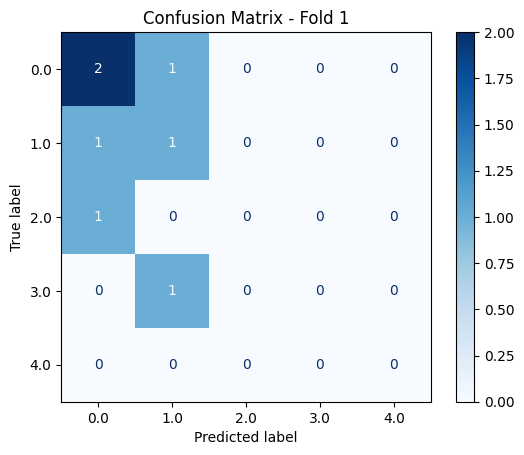


🔁 Fold 2/3
Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.1955 - loss: 1.7255 - val_accuracy: 0.0000e+00 - val_loss: 1.6931
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0929 - loss: 1.5234 - val_accuracy: 0.0000e+00 - val_loss: 1.6474
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4744 - loss: 1.3657 - val_accuracy: 0.0000e+00 - val_loss: 1.6159
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6186 - loss: 1.3619 - val_accuracy: 0.1429 - val_loss: 1.5982
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5160 - loss: 1.2668 - val_accuracy: 0.1429 - val_loss: 1.5886
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3814 - loss: 1.3392 - val_accuracy: 0.2857 - val_loss: 1.5747
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6603 - loss: 1.1150 - val_accuracy: 0.2857 - val_loss: 1.5634
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4231 - loss: 1.2091 - val_accuracy: 0

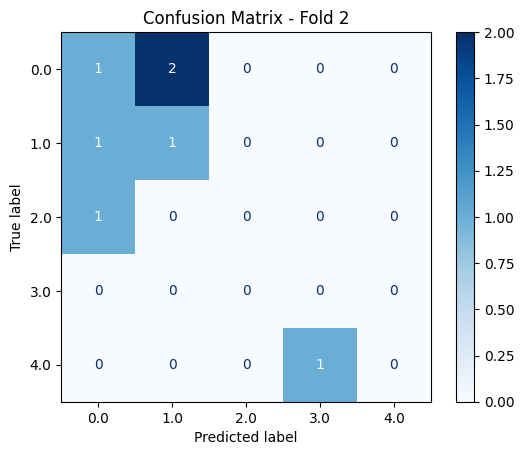


🔁 Fold 3/3
Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.1845 - loss: 1.7429 - val_accuracy: 0.5000 - val_loss: 1.5591
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3155 - loss: 1.5387 - val_accuracy: 0.5000 - val_loss: 1.4999
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2738 - loss: 1.5315 - val_accuracy: 0.6667 - val_loss: 1.4626
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3155 - loss: 1.3769 - val_accuracy: 0.6667 - val_loss: 1.4451
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3214 - loss: 1.4124 - val_accuracy: 0.6667 - val_loss: 1.4285
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5000 - loss: 1.1690 - val_accuracy: 0.6667 - val_loss: 1.4239
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6786 - loss: 1.1460 - val_accuracy: 0.5000 - val_loss: 1.4271
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5893 - loss: 0.9982 - val_accuracy: 0.3333 - val_

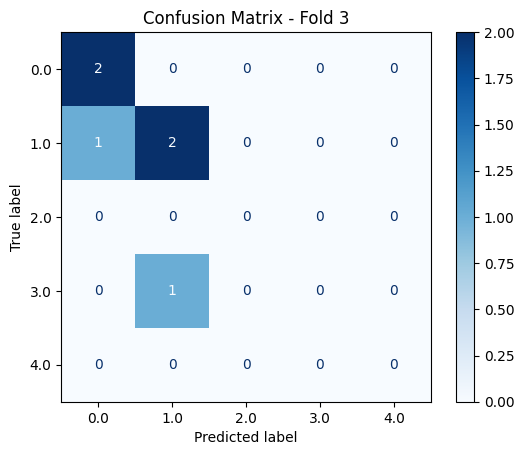

In [22]:
n_timesteps = X_seq.shape[1]
n_features = X_seq.shape[2]
n_static = X_static.shape[1]
n_classes = len(np.unique(y))

fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_seq, y)):
    print(f"\n🔁 Fold {fold + 1}/{n_splits}")

    # Split
    X_seq_train, X_seq_test = X_seq[train_idx], X_seq[test_idx]
    X_static_train, X_static_test = X_static[train_idx], X_static[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Build and train
    model = build_model(n_timesteps, n_features, n_static, n_classes)

    history = model.fit(
        [X_seq_train, X_static_train],
        y_train,
        validation_data=([X_seq_test, X_static_test], y_test),
        epochs=30,
        batch_size=8,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
        ],
        verbose=1,
    )

    # Evaluate model performance
    loss, acc = model.evaluate([X_seq_test, X_static_test], y_test, verbose=0)

    # Predict class probabilities and take argmax
    y_pred_probs = model.predict([X_seq_test, X_static_test])
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    # Calculate Mean Absolute Error (ordinal-aware)
    mae = mean_absolute_error(y_test, y_pred_classes)

    # 📊 Confusion Matrix
    labels = sorted(np.unique(y))
    cm = confusion_matrix(y_test, y_pred_classes, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - Fold {fold + 1}")
    plt.show()

    # Store both metrics
    fold_metrics.append({"fold": fold + 1, "accuracy": acc, "mae": mae})

Fold
Fold 1 - Class 0 and 1 dominate. Class 2 misclassified as 0. Class 4 never predicted.
Fold 2 - Class 4 gets one correct hit 🎯 — but class 2 is always misclassified.
Fold 3 - Class 2 and 4 are totally ignored. Only class 0, 1, 3 are seen.

In [23]:
# Extract accuracy and MAE from each fold
accs = [m["accuracy"] for m in fold_metrics]
maes = [m["mae"] for m in fold_metrics]
fold_ids = [m["fold"] for m in fold_metrics]

# Create a summary DataFrame
summary_df = pd.DataFrame(
    {"Fold": fold_ids, "Accuracy": np.round(accs, 4), "MAE": np.round(maes, 4)}
)

# Display the per-fold results
print("\n🎯 K-Fold Results Summary:")
print(summary_df)
print("\n")

# Print overall averages
print("Average Accuracy:", np.round(np.mean(accs), 4))
print("Average MAE:", np.round(np.mean(maes), 4))


🎯 K-Fold Results Summary:
   Fold  Accuracy     MAE
0     1    0.4286  0.8571
1     2    0.2857  0.8571
2     3    0.6667  0.5000


Average Accuracy: 0.4603
Average MAE: 0.7381


1. Replacing nan with 0
K-Fold Results Summary:
   Fold  Accuracy     MAE
0     1    0.2857  1.1429
1     2    0.1429  1.4286
2     3    0.5000  0.6667


Average Accuracy: 0.3095
Average MAE: 1.0794

2. Imputing with Mean
K-Fold Results Summary:
   Fold  Accuracy     MAE
0     1    0.2857  1.1429
1     2    0.2857  1.1429
2     3    0.6667  0.5000


Average Accuracy: 0.4127
Average MAE: 0.9286

# Sampling and Class Imbalance Methods

In [24]:
from sklearn.utils import class_weight
from imblearn.over_sampling import RandomOverSampler
import numpy as np


def handle_imbalance(X, y, strategy="none", model_type="tabular"):
    """
    Handles class imbalance using class weights or oversampling.
    Works with tabular or time series models.

    Parameters:
    - X: np.array or tuple (X_seq, X_static)
    - y: np.array
    - strategy: "none", "class_weight", "oversample"
    - model_type: "tabular" or "sequence"
    """
    if strategy == "none":
        return X, y, None

    elif strategy == "class_weight":
        weights = class_weight.compute_class_weight(
            class_weight="balanced", classes=np.unique(y), y=y
        )
        return X, y, dict(enumerate(weights))

    elif strategy == "oversample":
        if model_type == "sequence":
            raise ValueError("Oversampling not implemented for sequence data yet")

        ros = RandomOverSampler()
        X_resampled, y_resampled = ros.fit_resample(X, y)
        return X_resampled, y_resampled, None

## Usage for LSTM and tabular data

In [ ]:
# # For tabular
# X_tab, y, class_weights = handle_imbalance(
#     X_tab, y, strategy="oversample", model_type="tabular"
# )

# For LSTM
(X_seq, X_static), y, class_weights = handle_imbalance(
    (X_seq, X_static), y, strategy="class_weight", model_type="sequence"
)

# Pass class_weights into model.fit()

NameError: name 'X_tab' is not defined